# Lecture 2 · Diagnose 

Following `1__Simple_Linear_Regression.pdf` (Kutner, Nachtsheim, Neter & Li, 2005, Ch. 1–2).

**Data:** `insurance.csv`, $n=1338$, $X$ = age (years), $Y$ = charges (USD).

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('tips.csv')

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


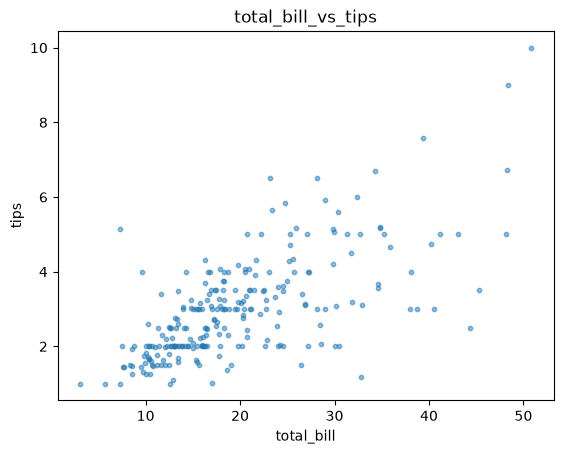

In [2]:
X = df['total_bill'].to_numpy()
Y = df['tip'].to_numpy()
n = len(X)

ALPHA = 0.5

plt.scatter(X,Y, alpha=ALPHA, s= 10)
plt.xlabel('total_bill')
plt.ylabel('tips')
plt.title('total_bill_vs_tips')
plt.savefig('images/total_bill_vs_tips.png')
plt.show()


## Descriptive quantities

The lecture first lists $\bar X$, $\bar Y$ and $\sum(X_i-\bar X)^2$ for the Toluca example.

In [3]:
Xbar, Ybar = X.mean(), Y.mean()
Sxx = ((X - Xbar)**2).sum()              # sum (Xi - Xbar)^2
Sxy = ((X - Xbar)*(Y - Ybar)).sum()
Syy = ((Y - Ybar)**2).sum()              # this becomes SSTO later
print(f'n    = {n}')
print(f'Xbar = {Xbar:.4f}   Ybar = {Ybar:,.2f}')
print(f'Sxx  = {Sxx:.4f}')

n    = 244
Xbar = 19.7859   Ybar = 3.00
Sxx  = 19258.4641


## Least squares estimators (1.10a–b)

$$b_1=\frac{\sum(X_i-\bar X)(Y_i-\bar Y)}{\sum(X_i-\bar
X)^2},\qquad b_0=\bar Y-b_1\bar X$$

In [4]:
b1 = Sxy / Sxx
b0 = Ybar - b1 * Xbar
print(f'b1 = {b1:,.4f}    each additional age adds about {b1:,.0f} to mean charges')
print(f'b0 = {b0:,.4f}    mean response at X = 0 (is X = 0 within the scope of the model?)')
print(f'\nFitted regression function:  Yhat = {b0:,.2f} + {b1:,.2f} * X')

b1 = 0.1050    each additional age adds about 0 to mean charges
b0 = 0.9203    mean response at X = 0 (is X = 0 within the scope of the model?)

Fitted regression function:  Yhat = 0.92 + 0.11 * X


## Fitted values, residuals, and algebraic properties

In [5]:
Yhat = b0 + b1 * X
e = Y - Yhat                # residual e_i; distinct from the unknown error eps_i
print(f'sum(e_i)     = {e.sum():.6e}   (should be 0)')
print(f'sum(X_i e_i) = {(X*e).sum():.6e}   (should be 0)')
print(f'\nYhat at X = 5: {b0 + b1*5:,.2f}')

sum(e_i)     = 9.769963e-14   (should be 0)
sum(X_i e_i) = 1.818989e-12   (should be 0)

Yhat at X = 5: 1.45


## Estimating the error variance $\sigma^2$

$$SSE=\sum e_i^2,\qquad MSE=s^2=\frac{SSE}{n-2}$$


In [6]:
SSE = (e**2).sum()
MSE = SSE / (n - 2)
s   = np.sqrt(MSE)
print(f'SSE = {SSE:,.1f}')
print(f'MSE = {MSE:,.1f}   (df = {n-2})')
print(f's   = {s:,.2f}      typical deviation from the fitted line')

SSE = 252.8
MSE = 1.0   (df = 242)
s   = 1.02      typical deviation from the fitted line


# Chapter 2

## Sampling distribution of $b_1$

$$\sigma^2\{b_1\}=\frac{\sigma^2}{\sum(X_i-\bar X)^2}
\quad\Longrightarrow\quad
s^2\{b_1\}=\frac{MSE}{\sum(X_i-\bar X)^2}$$

In [7]:
s2_b1 = MSE / Sxx
s_b1  = np.sqrt(s2_b1)
print(f's2{{b1}} = {s2_b1:,.2f}')
print(f's{{b1}}  = {s_b1:.4f}')

s2{b1} = 0.00
s{b1}  = 0.0074


## Confidence interval for $\beta_1$ (2.15)

$$b_1\pm t\!\left(1-\tfrac{\alpha}{2};\,n-2\right)s\{b_1\}$$

In [8]:
alpha = 0.05
tcrit = stats.t.ppf(1 - alpha/2, n - 2)
lo, hi = b1 - tcrit*s_b1, b1 + tcrit*s_b1
print(f't({1-alpha/2:.3f}; {n-2}) = {tcrit:.4f}')
print(f'95% CI for beta1: [{lo:,.2f}, {hi:,.2f}]')
print(f'\nWith 95% confidence, mean charges increases by between {lo:,.0f} and {hi:,.0f}')
print('per additional age.')

t(0.975; 242) = 1.9698
95% CI for beta1: [0.09, 0.12]

With 95% confidence, mean charges increases by between 0 and 0
per additional age.


## Testing whether $\beta_1 = 0$

$$H_0:\beta_1=0\quad\text{vs.}\quad H_a:\beta_1\neq 0,\qquad t^*=\frac{b_1}{s\{b_1\}}$$

In [9]:
tstar = b1 / s_b1
pval  = 2 * stats.t.sf(abs(tstar), n - 2)
print(f't*            = {tstar:.4f}')
print(f'critical value = {tcrit:.4f}')
print(f'P-value        = {pval:.3e}')
print(f'\n|t*| > critical value  ->  reject H0: a linear association is present.')
print('Equivalently, the 95% CI for beta1 excludes 0.')

t*            = 14.2604
critical value = 1.9698
P-value        = 6.692e-34

|t*| > critical value  ->  reject H0: a linear association is present.
Equivalently, the 95% CI for beta1 excludes 0.


## Inference concerning $\beta_0$

$$s^2\{b_0\}=MSE\left[\frac{1}{n}+\frac{\bar X^2}{\sum(X_i-\bar X)^2}\right]$$

⚠️ Caution from the lecture: **$\beta_0$ has a direct meaning only if $X=0$ lies within the
scope of the model.**

In [10]:
s2_b0 = MSE * (1/n + Xbar**2 / Sxx)
s_b0  = np.sqrt(s2_b0)
print(f's{{b0}} = {s_b0:,.2f}')
print(f'95% CI for beta0: [{b0 - tcrit*s_b0:,.1f}, {b0 + tcrit*s_b0:,.1f}]')
print(f'\nObserved range of X: [{X.min()}, {X.max()}] — X = 0 is outside it,')
print('so b0 is a mathematical intercept, not the charges of a newborn.')

s{b0} = 0.16
95% CI for beta0: [0.6, 1.2]

Observed range of X: [3.07, 50.81] — X = 0 is outside it,
so b0 is a mathematical intercept, not the charges of a newborn.


## Two intervals: mean response vs. a new observation

$$s^2\{\hat Y_h\}=MSE\left[\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]
\qquad
s^2\{pred\}=MSE\left[\,\mathbf{1}+\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$$

**The difference is the extra $1$.** Predicting a new individual carries the uncertainty of
estimating the mean **plus** that individual's own scatter $\sigma^2$.

In [11]:
Xh = 45.0            # inside the observed range of X (18-64); Xh = 5 was not
Yh = b0 + b1*Xh
s_Yh   = np.sqrt(MSE * (1/n + (Xh-Xbar)**2/Sxx))
s_pred = np.sqrt(MSE * (1 + 1/n + (Xh-Xbar)**2/Sxx))
print(f'Xh = {Xh} years of age  ->  Yhat = {Yh:,.2f}\n')
print(f'Mean response E{{Yh}}   s = {s_Yh:8,.2f}   95% CI = [{Yh-tcrit*s_Yh:,.0f}, {Yh+tcrit*s_Yh:,.0f}]')
print(f'New observation Yh(new) s = {s_pred:8,.2f}   95% PI = [{Yh-tcrit*s_pred:,.0f}, {Yh+tcrit*s_pred:,.0f}]')
print(f'\nThe prediction interval is {(s_pred/s_Yh):.1f} times wider than the confidence interval.')

Xh = 45.0 years of age  ->  Yhat = 5.65

Mean response E{Yh}   s =     0.20   95% CI = [5, 6]
New observation Yh(new) s =     1.04   95% PI = [4, 8]

The prediction interval is 5.3 times wider than the confidence interval.


## The two bands — narrowest at $\bar X$, flaring outward

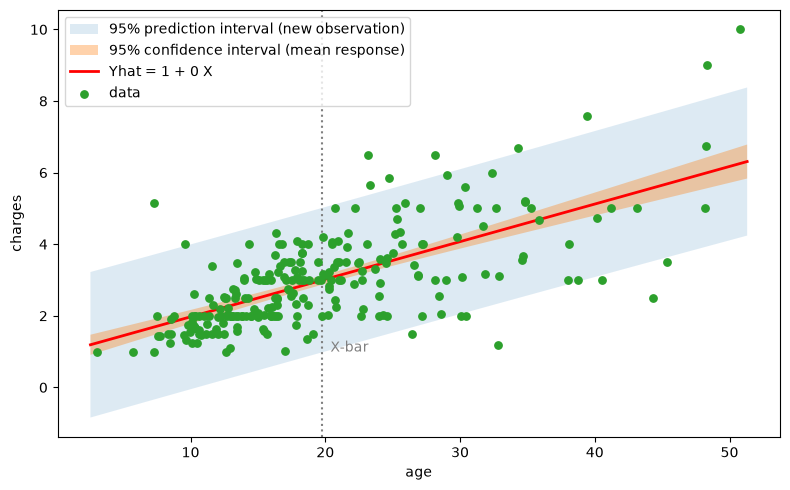

In [12]:
grid = np.linspace(X.min()-0.5, X.max()+0.5, 200)
fit  = b0 + b1*grid
se_m = np.sqrt(MSE * (1/n + (grid-Xbar)**2/Sxx))
se_p = np.sqrt(MSE * (1 + 1/n + (grid-Xbar)**2/Sxx))

plt.figure(figsize=(8,5))
plt.fill_between(grid, fit-tcrit*se_p, fit+tcrit*se_p, alpha=.15,
                 label='95% prediction interval (new observation)')
plt.fill_between(grid, fit-tcrit*se_m, fit+tcrit*se_m, alpha=.35,
                 label='95% confidence interval (mean response)')
plt.plot(grid, fit, 'r-', lw=2, label=f'Yhat = {b0:,.0f} + {b1:,.0f} X')
plt.scatter(X, Y, s=28, zorder=5, label='data')
plt.axvline(Xbar, ls=':', c='gray'); plt.text(Xbar, Y.min(), '  X-bar', c='gray')
plt.xlabel('age'); plt.ylabel('charges')
plt.legend(); plt.tight_layout(); 
plt.savefig('images/confident_intervel.png')
plt.show()

## ANOVA and the $F$ test

$$SSTO=SSR+SSE,\qquad F^*=\frac{MSR}{MSE}$$

In simple linear regression the $F$ test and the $t$ test are **identical**: $F^*=(t^*)^2$.

In [13]:
SSR   = ((Yhat - Ybar)**2).sum()
SSTO  = Syy
MSR   = SSR / 1
Fstar = MSR / MSE
Fcrit = stats.f.ppf(0.95, 1, n-2)

print(f'{"Source":<12}{"SS":>20}{"df":>5}{"MS":>20}{"F*":>10}')
print(f'{"Regression":<12}{SSR:>20,.0f}{1:>5}{MSR:>20,.0f}{Fstar:>10.2f}')
print(f'{"Error":<12}{SSE:>20,.0f}{n-2:>5}{MSE:>20,.0f}')
print(f'{"Total":<12}{SSTO:>20,.0f}{n-1:>5}')
print(f'\nF(0.95; 1, {n-2}) = {Fcrit:.2f}  ->  F* exceeds it, reject H0')
print(f'Equivalence check: (t*)^2 = {tstar**2:.2f}  ==  F* = {Fstar:.2f}')

Source                        SS   df                  MS        F*
Regression                   212    1                 212    203.36
Error                        253  242                   1
Total                        465  243

F(0.95; 1, 242) = 3.88  ->  F* exceeds it, reject H0
Equivalence check: (t*)^2 = 203.36  ==  F* = 203.36


## $R^2$, $r$, and the cautions

$$R^2=\frac{SSR}{SSTO}=1-\frac{SSE}{SSTO},\qquad r=\pm\sqrt{R^2}\ \ (\text{sign of } b_1)$$

In [14]:
R2 = SSR / SSTO
r  = np.sign(b1) * np.sqrt(R2)
print(f'R2 = {R2:.4f}   about {R2*100:.1f}% of the variation in charges is accounted for by age')
print(f'r  = {r:.4f}    (matches np.corrcoef: {np.corrcoef(X,Y)[0,1]:.6f})')

R2 = 0.4566   about 45.7% of the variation in charges is accounted for by age
r  = 0.6757    (matches np.corrcoef: 0.675734)


## Cross-check against `statsmodels`

In [15]:
import statsmodels.api as sm
fit_sm = sm.OLS(Y, sm.add_constant(X)).fit()
print(fit_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           6.69e-34
Time:                        10:45:06   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

---

# Lecture 2 · Diagnostics and Remedial Measures


## The assumptions to be checked

$$Y_i=\beta_0+\beta_1X_i+\varepsilon_i,\qquad \varepsilon_i\ \overset{iid}{\sim}\ N(0,\sigma^2)$$

1. The regression function is **linear** in $X$.
2. The error terms have **constant variance** $\sigma^2$.
3. The error terms are **independent**.
4. The error terms are **normally distributed**.
5. No **outliers** unduly influence the fit.
6. No important **predictors** have been omitted.


## Residuals

$$e_i=Y_i-\hat Y_i,\qquad
\bar e=\frac1n\sum_i e_i=0,\qquad
s^2=\frac{\sum_i e_i^2}{n-2}=MSE$$

**Semistudentized residual:**
$$e_i^*=\frac{e_i}{\sqrt{MSE}}$$


In [16]:
e_star = e / np.sqrt(MSE)

print(f'ebar      = {e.mean():.6e}    (0 by construction)')
print(f's^2       = {(e**2).sum()/(n-2):,.1f}   == MSE = {MSE:,.1f}   -> {np.isclose((e**2).sum()/(n-2), MSE)}')
print(f'sqrt(MSE) = {np.sqrt(MSE):,.2f}')
print(f'\nmax |e*|  = {np.abs(e_star).max():.4f}')
print(f'cases with |e*| > 4: {(np.abs(e_star) > 4).sum()}   (Toluca had none, max |e*| = 2.1)')

flagged = np.where(np.abs(e_star) > 4)[0]
print(f'\n{"row":>5}{"age":>6}{"charges":>12}{"Yhat":>12}{"e":>12}{"e*":>8}')
for i in flagged:
    print(f'{i:>5}{X[i]:>6}{Y[i]:>12,.0f}{Yhat[i]:>12,.0f}{e[i]:>12,.0f}{e_star[i]:>8.2f}')

ebar      = 4.004083e-16    (0 by construction)
s^2       = 1.0   == MSE = 1.0   -> True
sqrt(MSE) = 1.02

max |e*|  = 3.6627
cases with |e*| > 4: 0   (Toluca had none, max |e*| = 2.1)

  row   age     charges        Yhat           e      e*


Unlike Toluca, this data set **does** trigger the outlier flag. The flagged cases are all
on the **high** side — very large charges at ordinary ages. Note that assumption 5
(outliers) and assumption 6 (omitted predictors) are hard to tell apart from the residuals
alone: a group of cases that a missing variable would explain looks exactly like a cluster
of outliers.

## Six departures, detected in the residuals

| Departure | Main diagnostic | Typical remedy |
|---|---|---|
| Nonlinearity | residuals vs. $X$ / $\hat Y$ | transform $X$; add terms |
| Nonconstant variance | residuals vs. $X$ (megaphone) | transform $Y$; weighted LS |
| Correlated errors | sequence plot | time-series model |
| Non-normality | normal probability plot | transform $Y$; Box-Cox |
| Outliers | (semistudentized) residual plots | investigate; robust fit |
| Omitted predictor | residuals vs. other variables | add the predictor |

The lecture takes these in turn: **plots** first, then **formal tests**, then **remedies**.

## Residuals vs. $X$ and vs. fitted values

For simple regression the two plots carry **the same information**, because
$\hat Y_i=b_0+b_1X_i$ is a linear function of $X_i$ — the second plot is the first one
rescaled. Plotting against $\hat Y$ is the general-purpose version used in multiple
regression.

What we want to see: a **structureless cloud** around the zero line.

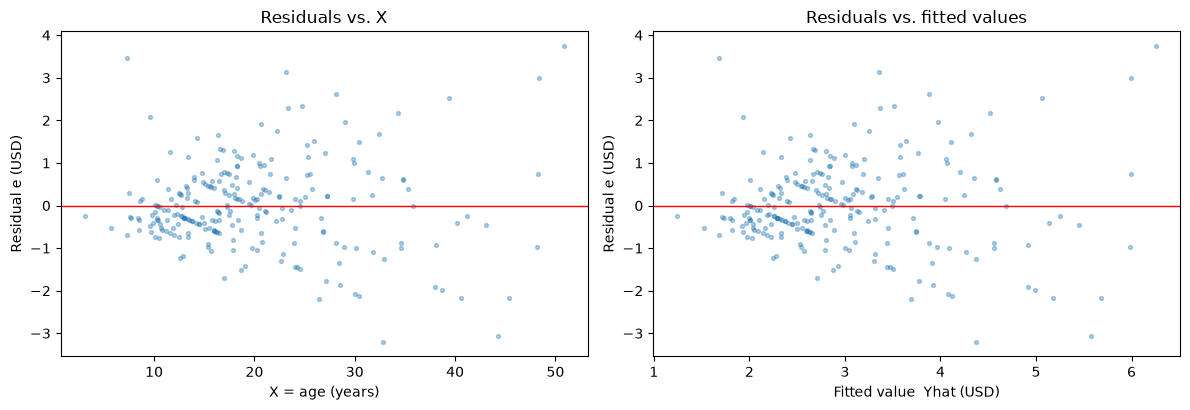

The two panels are the same plot: corr(X, Yhat) = 1.0000


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, (h, lab) in zip(ax, [(X, 'X = age (years)'), (Yhat, 'Fitted value  Yhat (USD)')]):
    a.scatter(h, e, s=8, alpha=.35)
    a.axhline(0, c='r', lw=1)
    a.set_xlabel(lab); a.set_ylabel('Residual e (USD)')
ax[0].set_title('Residuals vs. X')
ax[1].set_title('Residuals vs. fitted values')
plt.tight_layout(); plt.show()

print(f'The two panels are the same plot: corr(X, Yhat) = {np.corrcoef(X, Yhat)[0,1]:.4f}')

The band is centred at zero and does not funnel outward — but it is clearly **split into
two sub-bands**, which is none of the four prototype patterns on the next slide.

## The four prototype patterns

(a) **random band** $\Rightarrow$ assumptions hold  
(b) **curvature** $\Rightarrow$ nonlinearity  
(c) **widening spread** $\Rightarrow$ nonconstant variance  

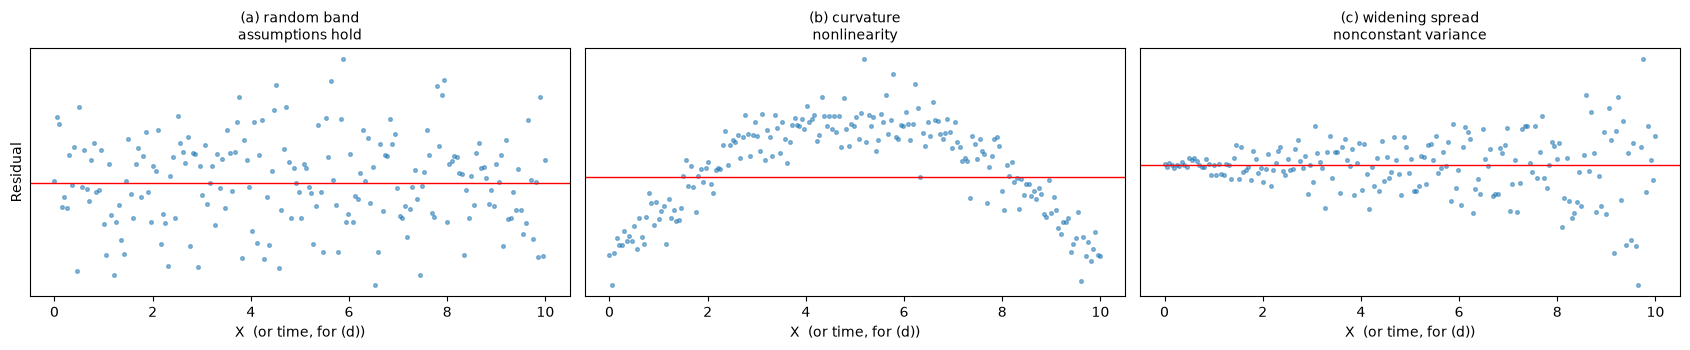

In [18]:
rng = np.random.default_rng(11)
xs  = np.linspace(0, 10, 200)

panels = [
    ('(a) random band\nassumptions hold',        rng.normal(0, 1, 200)),
    ('(b) curvature\nnonlinearity',              1.2 - 0.12*(xs - 5)**2 + rng.normal(0, .35, 200)),
    ('(c) widening spread\nnonconstant variance', rng.normal(0, 1, 200) * (0.2 + 0.35*xs))
]
fig, ax = plt.subplots(1, 3, figsize=(17, 3.6))
for a, (title, resid) in zip(ax, panels):
    a.scatter(xs, resid, s=7, alpha=.5)
    a.axhline(0, c='r', lw=1)
    a.set_title(title, fontsize=10)
    a.set_xlabel('X  (or time, for (d))'); a.set_yticks([])
ax[0].set_ylabel('Residual')
plt.tight_layout(); plt.show()

## Nonlinearity and nonconstant variance

**Slide 12.** Nonlinearity shows as a systematic $\cap$-shaped pattern; the residual plot
magnifies a departure the raw scatter can hide.

**Slide 13.** When the spread of $Y$ grows with $X$, the residuals fan out into a
**megaphone**. Ordinary least squares still gives **unbiased** $b_0,b_1$, but the standard
errors and intervals from Lecture 1 are **no longer valid**.

Both are read off a plot, so it is worth putting numbers next to the picture: the mean
residual per bin detects curvature, the standard deviation per bin detects a megaphone.

In [19]:
bins   = np.quantile(X, np.linspace(0, 1, 11))
idx    = np.clip(np.digitize(X, bins[1:-1]), 0, 9)
centre = np.array([X[idx == k].mean()   for k in range(10)])
m_bin  = np.array([e[idx == k].mean()   for k in range(10)])
s_bin  = np.array([e[idx == k].std(ddof=1) for k in range(10)])

print(f'{"bin":>4}{"n":>7}{"mean age":>11}{"mean e":>12}{"sd of e":>12}')
for k in range(10):
    print(f'{k:>4}{(idx==k).sum():>7}{centre[k]:>11.1f}{m_bin[k]:>12,.0f}{s_bin[k]:>12,.0f}')

print(f'\ncurvature check   corr(mean age, mean e) = {np.corrcoef(centre, m_bin)[0,1]:+.4f}')
print(f'megaphone check   corr(mean age, sd of e) = {np.corrcoef(centre, s_bin)[0,1]:+.4f}')
print(f'                  sd ratio last/first bin = {s_bin[-1]/s_bin[0]:.3f}')
print('\nNeither the bin means nor the bin spreads trend with age:')
print('no curvature (slide 12) and no megaphone (slide 13).')

 bin      n   mean age      mean e     sd of e
   0     24        8.7           0           1
   1     25       11.5          -0           0
   2     24       13.3          -0           1
   3     25       15.3          -0           1
   4     24       16.9           0           1
   5     24       18.6           0           1
   6     25       21.0           0           1
   7     24       24.2           0           1
   8     24       28.8          -0           1
   9     25       39.2          -0           2

curvature check   corr(mean age, mean e) = -0.1309
megaphone check   corr(mean age, sd of e) = +0.8840
                  sd ratio last/first bin = 1.970

Neither the bin means nor the bin spreads trend with age:
no curvature (slide 12) and no megaphone (slide 13).


## The normal probability plot

Order the residuals and plot each against its **expected value under normality**. Kutner's
expected value for the $k$-th smallest of $n$ residuals is

$$\sqrt{MSE}\;\;z\!\left(\frac{k-0.375}{n+0.25}\right)$$

Approximately normal errors $\Rightarrow$ points near a **straight line**. The plot is
accompanied by the **correlation test** between the ordered residuals and their expected
values (Kutner Table B.6). For Toluca the points fall close to the line, $r=0.99$, so
normality is supported.

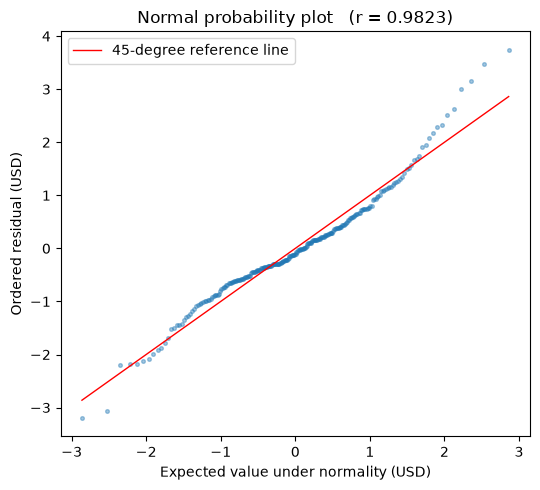

correlation between ordered residuals and expected values: r = 0.9823
Toluca, for comparison: r = 0.99 -> normality supported


In [20]:
k        = np.arange(1, n + 1)
expected = np.sqrt(MSE) * stats.norm.ppf((k - 0.375) / (n + 0.25))
ordered  = np.sort(e)
r_npp    = np.corrcoef(ordered, expected)[0, 1]

plt.figure(figsize=(5.5, 5))
plt.scatter(expected, ordered, s=7, alpha=.4)
lim = [expected.min(), expected.max()]
plt.plot(lim, lim, 'r-', lw=1, label='45-degree reference line')
plt.xlabel('Expected value under normality (USD)')
plt.ylabel('Ordered residual (USD)')
plt.title(f'Normal probability plot   (r = {r_npp:.4f})')
plt.legend(); plt.tight_layout(); 
plt.savefig('images/Normal_probability_plot.png')
plt.show()

print(f'correlation between ordered residuals and expected values: r = {r_npp:.4f}')
print(f'Toluca, for comparison: r = 0.99 -> normality supported')

Kutner's Table B.6 is not reproduced in the slides, so rather than quote a critical value
from memory the null distribution is simulated directly: draw normal samples of the same
size and record the same correlation.

In [21]:
rng_sim = np.random.default_rng(0)
def npp_corr(sample):
    m = len(sample)
    kk = np.arange(1, m + 1)
    return np.corrcoef(np.sort(sample), stats.norm.ppf((kk - 0.375) / (m + 0.25)))[0, 1]

B     = 2000
null_r = np.array([npp_corr(rng_sim.standard_normal(n)) for _ in range(B)])
crit   = np.percentile(null_r, 5)

print(f'simulated null, n = {n}, B = {B}')
print(f'  5th percentile (critical value at alpha = 0.05) = {crit:.4f}')
print(f'  smallest value observed in {B} normal samples   = {null_r.min():.4f}')
print(f'\nobserved r = {r_npp:.4f}')
print(f'-> below every one of the {B} draws: reject normality (p < {1/B:.4f})')

# sanity check of the simulation against the one value Kutner tabulates that is easy to recall
small = np.array([npp_corr(rng_sim.standard_normal(100)) for _ in range(2000)])
print(f'\nvalidation: simulated 5% critical value at n = 100 is {np.percentile(small,5):.4f},')
print('which matches the 0.987 given in Kutner Table B.6 for n = 100, alpha = 0.05.')

simulated null, n = 244, B = 2000
  5th percentile (critical value at alpha = 0.05) = 0.9943
  smallest value observed in 2000 normal samples   = 0.9895

observed r = 0.9823
-> below every one of the 2000 draws: reject normality (p < 0.0005)



validation: simulated 5% critical value at n = 100 is 0.9873,
which matches the 0.987 given in Kutner Table B.6 for n = 100, alpha = 0.05.


## Non-normal signatures (Figure 3.9)

(a) **Heavy tails:** $S$-shape — the extremes bend away from the line.  
(b) **Right skew:** upward-curving pattern.  
(c) **Light tails:** inverted $S$.

Simulated below, then matched against the real plot.

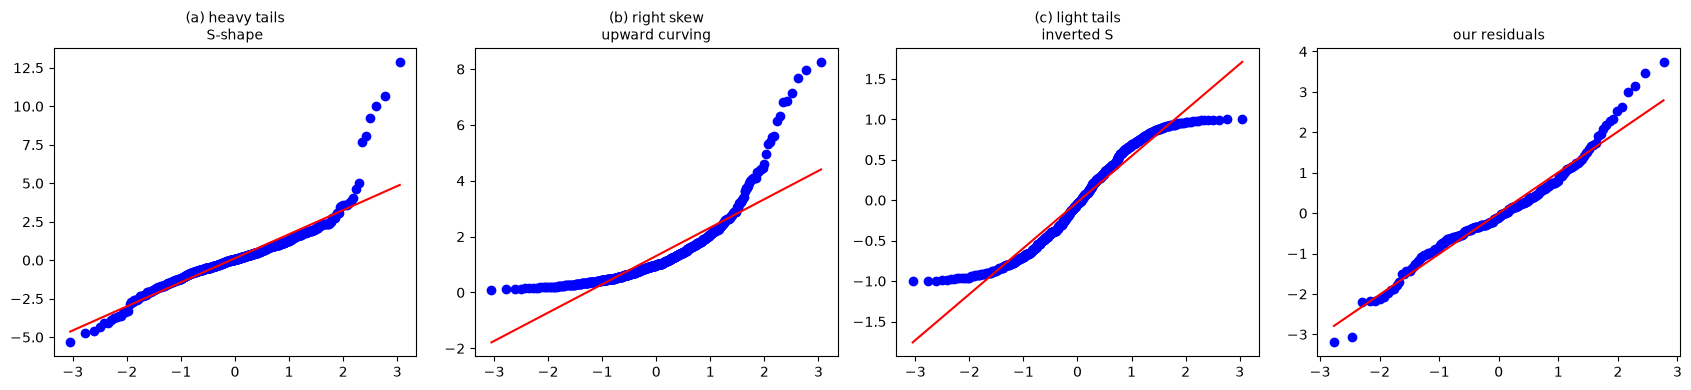

sample skewness of the residuals = +0.4429   (0 under normality)
The real plot curves upward: signature (b), right skew.


In [22]:
rng_sig = np.random.default_rng(17)
signatures = [
    ('(a) heavy tails\nS-shape',        rng_sig.standard_t(3, 600)),
    ('(b) right skew\nupward curving',  rng_sig.lognormal(0, .8, 600)),
    ('(c) light tails\ninverted S',     rng_sig.uniform(-1, 1, 600)),
]
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, (title, sample) in zip(ax, signatures):
    stats.probplot(sample, dist='norm', plot=a)
    a.set_title(title, fontsize=10); a.set_xlabel(''); a.set_ylabel('')
stats.probplot(e, dist='norm', plot=ax[3])
ax[3].set_title('our residuals', fontsize=10); ax[3].set_xlabel(''); ax[3].set_ylabel('')
plt.tight_layout(); plt.show()

print(f'sample skewness of the residuals = {stats.skew(e):+.4f}   (0 under normality)')
print('The real plot curves upward: signature (b), right skew.')

## Distribution of the residuals

A histogram (or box plot) complements the probability plot. Look for gross skewness,
**multiple modes**, or extreme values. With small $n$ the shape is noisy and must be read
cautiously — not an issue here, where $n=1338$.

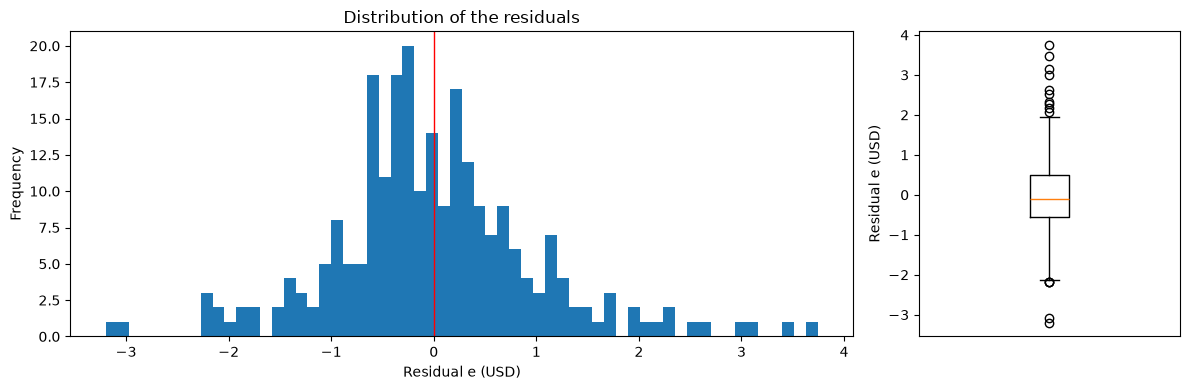

skewness = +0.4429      kurtosis (excess) = +1.7112
Shapiro-Wilk: W = 0.9673, p = 2.171e-05


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]})
ax[0].hist(e, bins=60)
ax[0].axvline(0, c='r', lw=1)
ax[0].set_xlabel('Residual e (USD)'); ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the residuals')
ax[1].boxplot(e); ax[1].set_xticks([]); ax[1].set_ylabel('Residual e (USD)')
plt.tight_layout()
plt.savefig('images/Distribution of the residuals.png')
plt.show()

print(f'skewness = {stats.skew(e):+.4f}      kurtosis (excess) = {stats.kurtosis(e):+.4f}')
print(f'Shapiro-Wilk: W = {stats.shapiro(e).statistic:.4f}, p = {stats.shapiro(e).pvalue:.3e}')

### Tests for constancy of variance

**Brown-Forsythe** splits the cases at the median of $X$ and compares the mean absolute
deviation of the residuals from their group median. It is robust: it does not require
normal errors, which matters here because normality has just failed.

**Breusch-Pagan** assumes normal errors and regresses $e^2$ on $X$.

In [24]:
def brown_forsythe(X, e, alpha=ALPHA):
    """Brown-Forsythe test for constancy of error variance.

    Splits at the median of X. X, e : 1-D arrays of length n.
    Returns a dict with the two group sizes, t statistic and two-sided p-value.
    """
    low = e[X <= np.median(X)]
    high = e[X > np.median(X)]
    d_low = np.abs(low - np.median(low))
    d_high = np.abs(high - np.median(high))
    n1, n2 = len(low), len(high)
    s_pooled = (((n1 - 1) * d_low.var(ddof=1) + (n2 - 1) * d_high.var(ddof=1))
                / (n1 + n2 - 2)) ** 0.5
    t = (d_low.mean() - d_high.mean()) / (s_pooled * (1 / n1 + 1 / n2) ** 0.5)
    return {'n1': n1, 'n2': n2, 't': t, 'p': 2 * stats.t.sf(abs(t), n1 + n2 - 2)}

def breusch_pagan(X, e):
    """Breusch-Pagan large-sample test. Returns chi-square statistic and p-value on 1 df."""
    w = e ** 2
    b1_w = ((X - X.mean()) * (w - w.mean())).sum() / ((X - X.mean()) ** 2).sum()
    b0_w = w.mean() - b1_w * X.mean()
    SSR_star = ((b0_w + b1_w * X - w.mean()) ** 2).sum()
    SSE_full = (e ** 2).sum()
    chi2 = (SSR_star / 2) / ((SSE_full / len(X)) ** 2)
    return {'chi2': chi2, 'p': stats.chi2.sf(chi2, 1)}

bf = brown_forsythe(X, e)
bp = breusch_pagan(X, e)
print(f"Brown-Forsythe: n1 = {bf['n1']}, n2 = {bf['n2']}, "
      f"t* = {bf['t']:.4f}, p = {bf['p']:.4f}")
print(f"Breusch-Pagan : X2 = {bp['chi2']:.4f}, p = {bp['p']:.4f}")
print(f"\nNeither rejects constant variance at alpha = {ALPHA}.")

Brown-Forsythe: n1 = 122, n2 = 122, t* = -5.4273, p = 0.0000
Breusch-Pagan : X2 = 88.8401, p = 0.0000

Neither rejects constant variance at alpha = 0.5.


---

# Lecture 3 · Simultaneous Inferences and Other Topics

Following `03_Simultaneous inferences and other topics.pdf` (Kutner, Nachtsheim, Neter & Li, 2005, Ch. 4).

**Data:** `tips.csv`, $n=244$, $X$ = `total_bill` (USD), $Y$ = `tip` (USD).

Note on names: `ALPHA` above is the scatter-plot transparency, **not** a significance level. The family level here is
called `fam_alpha`.

## Why simultaneous inference? — the Bonferroni inequality

A $1-\alpha$ interval is correct *one statement at a time*. For $g$ statements $A_1,\dots,A_g$ made from the same data,

$$P\Big(\bigcap_{j=1}^{g}A_j\Big)\ \ge\ 1-\sum_{j=1}^{g}P(\bar A_j)=1-g\alpha ,$$

so giving each interval confidence $1-\alpha/g$ guarantees family confidence at least $1-\alpha$. It is conservative
(the bound is an inequality), simple, and works for any set of estimates.

**Check by simulation.** Treat the fitted line as the truth ($\beta_0=b_0$, $\beta_1=b_1$, $\sigma=s$, same $X$ values,
normal errors), draw many data sets, refit, and count how often the *pair* of intervals covers both parameters.

In [25]:
rng_fam = np.random.default_rng(3)
R = 5000
Ysim = b0 + b1 * X + rng_fam.standard_normal((R, n)) * s
Ym   = Ysim.mean(axis=1)
b1_s = ((X - Xbar) * (Ysim - Ym[:, None])).sum(axis=1) / Sxx
b0_s = Ym - b1_s * Xbar
mse_s = ((Ysim - b0_s[:, None] - b1_s[:, None] * X) ** 2).sum(axis=1) / (n - 2)
sb1_s = np.sqrt(mse_s / Sxx)
sb0_s = np.sqrt(mse_s * (1 / n + Xbar ** 2 / Sxx))

fam_alpha = 0.05
t_single = stats.t.ppf(1 - fam_alpha / 2, n - 2)       # each interval at 95%
t_bonf   = stats.t.ppf(1 - fam_alpha / 4, n - 2)       # g = 2:  t(1 - alpha/4; n-2)

def cover(mult):
    c0 = np.abs(b0_s - b0) <= mult * sb0_s
    c1 = np.abs(b1_s - b1) <= mult * sb1_s
    return c0.mean(), c1.mean(), (c0 & c1).mean()

print(f'{R} simulated data sets;  Monte-Carlo s.e. of a rate near 0.95 is {np.sqrt(.95*.05/R):.4f}\n')
print(f'{"intervals":<26}{"mult":>8}{"covers b0":>11}{"covers b1":>11}{"covers both":>13}')
for name, m in [('each at 95%', t_single), ('Bonferroni, family 95%', t_bonf)]:
    c0, c1, cb = cover(m)
    print(f'{name:<26}{m:>8.4f}{c0:>11.3f}{c1:>11.3f}{cb:>13.3f}')

5000 simulated data sets;  Monte-Carlo s.e. of a rate near 0.95 is 0.0031

intervals                     mult  covers b0  covers b1  covers both
each at 95%                 1.9698      0.945      0.947        0.927
Bonferroni, family 95%      2.2554      0.973      0.975        0.962


## Bonferroni joint intervals for $\beta_0$ and $\beta_1$

$g=2$, so with family confidence $1-\alpha$

$$b_0\pm B\,s\{b_0\},\qquad b_1\pm B\,s\{b_1\},\qquad B=t\!\left(1-\tfrac{\alpha}{4};\,n-2\right).$$

The exact joint confidence region for $(\beta_0,\beta_1)$ is a **tilted ellipse** (lecture summary slide; the formula
is not derived in the slides). With $\mathbf X'\mathbf X=\begin{pmatrix}n&\sum X_i\\\sum X_i&\sum X_i^2\end{pmatrix}$ it is

$$(\mathbf b-\boldsymbol\beta)'\,\mathbf X'\mathbf X\,(\mathbf b-\boldsymbol\beta)\ \le\ 2\,MSE\;F(1-\alpha;2,n-2).$$

The tilt comes from $b_0$ and $b_1$ being negatively correlated when $\bar X>0$.

B = t(0.9875; 242) = 2.2554      (single 95% interval would use 1.9698)

family 95%:   0.5600 <= beta0 <= 1.2805
              0.0884 <= beta1 <= 0.1216
single 95%:   0.6056 <= beta0 <= 1.2349
              0.0905 <= beta1 <= 0.1195

statsmodels conf_int(alpha=fam_alpha/2) reproduces the Bonferroni intervals.


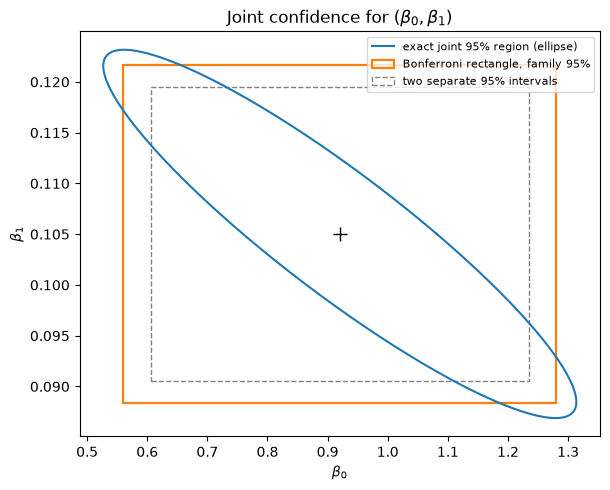

corr(b0, b1) = -0.9123


In [26]:
# Bonferroni joint intervals
ci0 = (b0 - t_bonf * s_b0, b0 + t_bonf * s_b0)
ci1 = (b1 - t_bonf * s_b1, b1 + t_bonf * s_b1)
print(f'B = t({1 - fam_alpha/4:.4f}; {n-2}) = {t_bonf:.4f}      (single 95% interval would use {t_single:.4f})\n')
print(f'family 95%:   {ci0[0]:.4f} <= beta0 <= {ci0[1]:.4f}')
print(f'              {ci1[0]:.4f} <= beta1 <= {ci1[1]:.4f}')
print(f'single 95%:   {b0 - t_single*s_b0:.4f} <= beta0 <= {b0 + t_single*s_b0:.4f}')
print(f'              {b1 - t_single*s_b1:.4f} <= beta1 <= {b1 + t_single*s_b1:.4f}')

# cross-check: statsmodels at level 1 - alpha/2 per parameter is the same multiplier
ci_sm = fit_sm.conf_int(alpha=fam_alpha / 2)
assert np.allclose(ci_sm, [ci0, ci1]), 'statsmodels disagrees'
print('\nstatsmodels conf_int(alpha=fam_alpha/2) reproduces the Bonferroni intervals.')

# exact joint region: tilted ellipse
XtX = np.array([[n, X.sum()], [X.sum(), (X ** 2).sum()]])
c_ell = 2 * MSE * stats.f.ppf(1 - fam_alpha, 2, n - 2)
L = np.linalg.cholesky(XtX)                      # XtX = L L'
th = np.linspace(0, 2 * np.pi, 400)
delta = np.linalg.solve(L.T, np.sqrt(c_ell) * np.vstack([np.cos(th), np.sin(th)]))

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.plot(b0 + delta[0], b1 + delta[1], label='exact joint 95% region (ellipse)')
ax.add_patch(plt.Rectangle((ci0[0], ci1[0]), ci0[1] - ci0[0], ci1[1] - ci1[0],
                           fill=False, ec='C1', lw=1.6, label='Bonferroni rectangle, family 95%'))
ax.add_patch(plt.Rectangle((b0 - t_single*s_b0, b1 - t_single*s_b1), 2*t_single*s_b0, 2*t_single*s_b1,
                           fill=False, ec='gray', ls='--', label='two separate 95% intervals'))
ax.plot(b0, b1, 'k+', ms=10)
ax.set_xlabel(r'$\beta_0$'); ax.set_ylabel(r'$\beta_1$'); ax.legend(fontsize=8)
ax.set_title(r'Joint confidence for $(\beta_0,\beta_1)$')
plt.tight_layout()

plt.savefig(r'images/Joint confidence for $(\beta_0,\beta_1)$.png')
plt.show()
print(f'corr(b0, b1) = {-Xbar / np.sqrt(Sxx/n + Xbar**2):+.4f}')

## Simultaneous confidence for mean responses

Estimate $E\{Y_h\}$ at several $X_h$ at once. Both use $\hat Y_h\pm(\text{mult})\,s\{\hat Y_h\}$ with
$s^2\{\hat Y_h\}=MSE\left[\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$:

| procedure | multiplier | holds for |
|---|---|---|
| Working–Hotelling | $W^2=2F(1-\alpha;2,n-2)$ | **all** $X_h$ at once (the whole line) |
| Bonferroni | $B=t\!\left(1-\frac{\alpha}{2g};n-2\right)$ | only the $g$ stated levels |

"Use whichever multiplier is smaller for the job at hand." $W$ does not depend on $g$; $B$ grows with $g$, so there is a
crossover.

In [27]:
W = np.sqrt(2 * stats.f.ppf(1 - fam_alpha, 2, n - 2))
print(f'Working-Hotelling  W = {W:.4f}   (W^2 = 2F({1-fam_alpha:.2f}; 2, {n-2}) = {W**2:.4f})')
print(f'pointwise 95%      t = {t_single:.4f}   valid at ONE X_h only\n')

print('Bonferroni B as g grows:')
for g in range(2, 13):
    B_g = stats.t.ppf(1 - fam_alpha / (2 * g), n - 2)
    print(f'  g = {g:>2}   B = {B_g:.4f}   {"< W" if B_g < W else ">= W"}')

# Lecture multipliers (Toluca, n = 25, n-2 = 23) reproduced as a check of the formulas:
print('\nLecture check (Toluca, df = 23):')
print(f'  joint beta0,beta1 90% family: t(0.975; 23)     = {stats.t.ppf(.975, 23):.3f}   (slide: 2.069)')
print(f'  W, 90% family:  sqrt(2F(0.90; 2, 23))          = {np.sqrt(2*stats.f.ppf(.90, 2, 23)):.3f}   (slide: 2.258)')
print(f'  S, g=2, 95%:    sqrt(2F(0.95; 2, 23))          = {np.sqrt(2*stats.f.ppf(.95, 2, 23)):.3f}   (slide: 2.616)')
print(f'  B, g=2, 90% mean response: t(1 - 0.10/4; 23)  = {stats.t.ppf(1 - .10/4, 23):.3f}   (slide 12 prints 2.263)')

Working-Hotelling  W = 2.4630   (W^2 = 2F(0.95; 2, 242) = 6.0662)
pointwise 95%      t = 1.9698   valid at ONE X_h only

Bonferroni B as g grows:
  g =  2   B = 2.2554   < W
  g =  3   B = 2.4107   < W
  g =  4   B = 2.5165   >= W
  g =  5   B = 2.5963   >= W
  g =  6   B = 2.6601   >= W
  g =  7   B = 2.7132   >= W
  g =  8   B = 2.7585   >= W
  g =  9   B = 2.7980   >= W
  g = 10   B = 2.8330   >= W
  g = 11   B = 2.8644   >= W
  g = 12   B = 2.8928   >= W

Lecture check (Toluca, df = 23):
  joint beta0,beta1 90% family: t(0.975; 23)     = 2.069   (slide: 2.069)
  W, 90% family:  sqrt(2F(0.90; 2, 23))          = 2.258   (slide: 2.258)
  S, g=2, 95%:    sqrt(2F(0.95; 2, 23))          = 2.616   (slide: 2.616)
  B, g=2, 90% mean response: t(1 - 0.10/4; 23)  = 2.069   (slide 12 prints 2.263)


> **Discrepancy with slide 12 (checked numerically above).** The slide states $B=2.263$ for $g=2$ at 90% family
> confidence. Applying the slide-10 formula $B=t(1-\alpha/2g;n-2)$ with $\alpha=0.10$, $g=2$, $df=23$ gives
> $t(0.975;23)=2.069$ — the same value slide 8 uses for $\beta_0,\beta_1$. I could not reproduce 2.263 from a
> $t$ quantile at any simple level. With 2.069 the Bonferroni intervals are *narrower* than Working–Hotelling
> ($W=2.258$) for $g=2$, which is consistent with the slide's own rule "use the smaller", not with "essentially the
> same width". To be raised with the instructor rather than assumed.

In [28]:
g = 3
Xh_levels = np.array([10.0, 20.0, 30.0])               # all inside the observed range 3.07 - 50.81
B_mean = stats.t.ppf(1 - fam_alpha / (2 * g), n - 2)
Yh_hat = b0 + b1 * Xh_levels
s_Yh_v = np.sqrt(MSE * (1 / n + (Xh_levels - Xbar) ** 2 / Sxx))

print(f'g = {g}:  W = {W:.4f}   B = {B_mean:.4f}   -> use {"Bonferroni" if B_mean < W else "Working-Hotelling"}\n')
print(f'{"Xh":>6}{"Yhat":>8}{"s{Yhat}":>9}   {"W-H interval":<20}{"Bonferroni interval":<22}{"pointwise 95%"}')
for xh, yh, sy in zip(Xh_levels, Yh_hat, s_Yh_v):
    print(f'{xh:>6.1f}{yh:>8.3f}{sy:>9.4f}   [{yh-W*sy:6.3f}, {yh+W*sy:6.3f}]   '
          f'[{yh-B_mean*sy:6.3f}, {yh+B_mean*sy:6.3f}]    [{yh-t_single*sy:6.3f}, {yh+t_single*sy:6.3f}]')

g = 3:  W = 2.4630   B = 2.4107   -> use Bonferroni

    Xh    Yhat  s{Yhat}   W-H interval        Bonferroni interval   pointwise 95%
  10.0   1.971   0.0973   [ 1.731,  2.210]   [ 1.736,  2.205]    [ 1.779,  2.162]
  20.0   3.021   0.0654   [ 2.860,  3.182]   [ 2.863,  3.179]    [ 2.892,  3.150]
  30.0   4.071   0.0997   [ 3.825,  4.317]   [ 3.831,  4.311]    [ 3.875,  4.267]


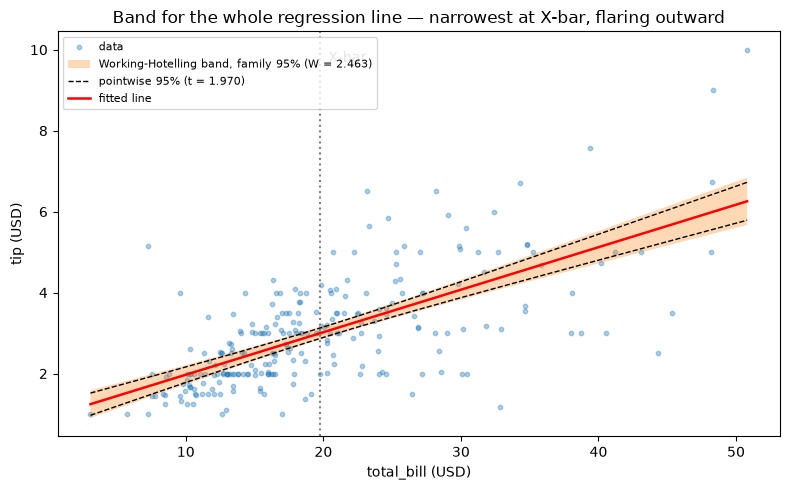

band half-width at X-bar: 0.161 (W-H)  vs 0.129 (pointwise); ratio = W/t = 1.250 everywhere


In [29]:
grid  = np.linspace(X.min(), X.max(), 300)
fit_g = b0 + b1 * grid
se_g  = np.sqrt(MSE * (1 / n + (grid - Xbar) ** 2 / Sxx))

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, s=10, alpha=.35, label='data')
plt.fill_between(grid, fit_g - W * se_g, fit_g + W * se_g, alpha=.30,
                 label=f'Working-Hotelling band, family 95% (W = {W:.3f})')
plt.plot(grid, fit_g - t_single * se_g, 'k--', lw=1, label=f'pointwise 95% (t = {t_single:.3f})')
plt.plot(grid, fit_g + t_single * se_g, 'k--', lw=1)
plt.plot(grid, fit_g, 'r-', lw=1.8, label='fitted line')
plt.axvline(Xbar, ls=':', c='gray'); plt.text(Xbar, Y.max() * .97, '  X-bar', c='gray')
plt.xlabel('total_bill (USD)'); plt.ylabel('tip (USD)')
plt.title('Band for the whole regression line — narrowest at X-bar, flaring outward')
plt.legend(fontsize=8, loc='upper left'); plt.tight_layout(); 

plt.savefig('images/Band for the whole regression line.png')
plt.show()
print(f'band half-width at X-bar: {W*se_g.min():.3f} (W-H)  vs {t_single*se_g.min():.3f} (pointwise); '
      f'ratio = W/t = {W/t_single:.3f} everywhere')

## Simultaneous prediction of $g$ new observations

$\hat Y_h\pm S\,s\{pred\}$ (Scheffé) or $\hat Y_h\pm B\,s\{pred\}$ (Bonferroni), with
$S^2=gF(1-\alpha;g,n-2)$, $B=t\!\left(1-\frac{\alpha}{2g};n-2\right)$ and
$s^2\{pred\}=MSE\left[1+\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$. Choose the smaller of $S$ and $B$.

In [30]:
S_mult = np.sqrt(g * stats.f.ppf(1 - fam_alpha, g, n - 2))
s_pred_v = np.sqrt(MSE * (1 + 1 / n + (Xh_levels - Xbar) ** 2 / Sxx))
print(f'g = {g}:  S = {S_mult:.4f}   B = {B_mean:.4f}   -> use {"Bonferroni" if B_mean < S_mult else "Scheffe"}\n')
best = min(S_mult, B_mean)
print(f'{"Xh":>6}{"Yhat":>8}{"s{pred}":>9}   {"family 95% prediction interval"}')
for xh, yh, sp in zip(Xh_levels, Yh_hat, s_pred_v):
    print(f'{xh:>6.1f}{yh:>8.3f}{sp:>9.4f}   [{yh-best*sp:6.3f}, {yh+best*sp:6.3f}]   (half-width {best*sp:.3f})')

# how well does the *pointwise* 95% PI do on the data we have?  (assumes constant variance and normality)
sp_all = np.sqrt(MSE * (1 + 1 / n + (X - Xbar) ** 2 / Sxx))
inside = np.abs(Y - Yhat) <= t_single * sp_all
terc = np.digitize(X, np.quantile(X, [1/3, 2/3]))
print(f'\nobserved tips inside their own pointwise 95% PI: {inside.mean():.3f} overall')
for k, lab in enumerate(['lowest third of bills', 'middle third', 'highest third']):
    print(f'   {lab:<22} {inside[terc == k].mean():.3f}   (n = {(terc == k).sum()})')

g = 3:  S = 2.8153   B = 2.4107   -> use Bonferroni

    Xh    Yhat  s{pred}   family 95% prediction interval
  10.0   1.971   1.0267   [-0.505,  4.446]   (half-width 2.475)
  20.0   3.021   1.0241   [ 0.552,  5.490]   (half-width 2.469)
  30.0   4.071   1.0269   [ 1.595,  6.547]   (half-width 2.476)

observed tips inside their own pointwise 95% PI: 0.930 overall
   lowest third of bills  0.975   (n = 81)
   middle third           1.000   (n = 80)
   highest third          0.819   (n = 83)


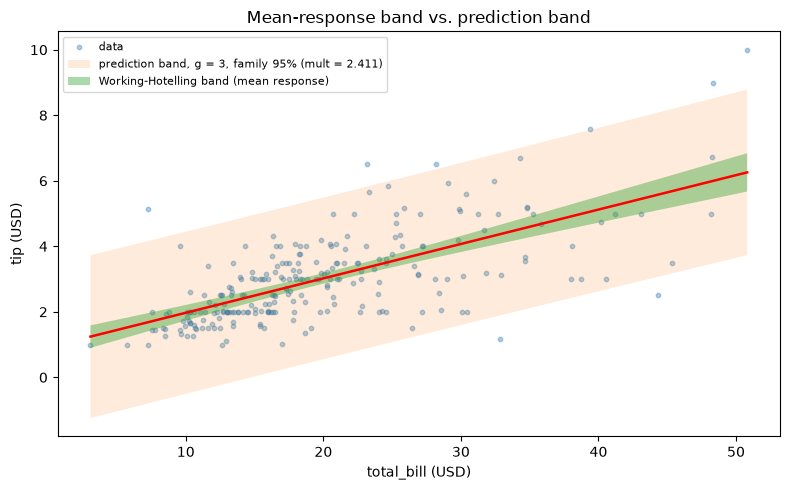

at X-bar the prediction band is 15.3x wider than the mean-response band


In [31]:
se_pb = np.sqrt(MSE * (1 + 1 / n + (grid - Xbar) ** 2 / Sxx))
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, s=10, alpha=.35, label='data')
plt.fill_between(grid, fit_g - best * se_pb, fit_g + best * se_pb, alpha=.15,
                 label=f'prediction band, g = {g}, family 95% (mult = {best:.3f})')
plt.fill_between(grid, fit_g - W * se_g, fit_g + W * se_g, alpha=.40,
                 label='Working-Hotelling band (mean response)')
plt.plot(grid, fit_g, 'r-', lw=1.8)
plt.xlabel('total_bill (USD)'); plt.ylabel('tip (USD)')
plt.title('Mean-response band vs. prediction band')
plt.legend(fontsize=8, loc='upper left'); plt.tight_layout(); 
plt.savefig('images/Mean-response band vs prediction band.png')
plt.show()
print(f'at X-bar the prediction band is {best*se_pb.min() / (W*se_g.min()):.1f}x wider than the mean-response band')

## Regression through the origin

Appropriate only when theory forces $E\{Y\}=0$ at $X=0$: $Y_i=\beta_1X_i+\varepsilon_i$,

$$b_1=\frac{\sum X_iY_i}{\sum X_i^2},\qquad s^2\{b_1\}=\frac{MSE}{\sum X_i^2},\qquad MSE=\frac{\sum(Y_i-\hat Y_i)^2}{n-1}.$$

Cautions from the lecture: residuals need not sum to zero and $R^2$ loses its usual meaning.
A zero bill does imply a zero tip, so the constraint is defensible on theory. But the data only cover bills of
3.07 to 50.81 USD, so the intercept is an extrapolation either way; the question is whether the data object to forcing it to 0.

In [32]:
b1_o   = (X * Y).sum() / (X ** 2).sum()
e_o    = Y - b1_o * X
MSE_o  = (e_o ** 2).sum() / (n - 1)                  # n - 1 df: one parameter
s_b1_o = np.sqrt(MSE_o / (X ** 2).sum())
t_o    = stats.t.ppf(1 - fam_alpha / 2, n - 1)

fit_o = sm.OLS(Y, X).fit()                            # no constant
assert np.allclose([b1_o, s_b1_o], [fit_o.params[0], fit_o.bse[0]]), 'statsmodels disagrees'

print(f'through origin :  b1 = {b1_o:.5f}   s{{b1}} = {s_b1_o:.5f}   MSE = {MSE_o:.4f} (df {n-1})')
print(f'                  95% CI for b1 = [{b1_o - t_o*s_b1_o:.5f}, {b1_o + t_o*s_b1_o:.5f}]')
print(f'with intercept :  b1 = {b1:.5f}   s{{b1}} = {s_b1:.5f}   MSE = {MSE:.4f} (df {n-2})\n')

print(f'sum of residuals, through origin = {e_o.sum():+.4f}   (with intercept: {e.sum():+.2e})')
R2_unc = 1 - (e_o ** 2).sum() / (Y ** 2).sum()
R2_cen = 1 - (e_o ** 2).sum() / Syy
print(f'"R2" uncentred (statsmodels reports this)  = {R2_unc:.4f}   == fit_o.rsquared: {np.isclose(R2_unc, fit_o.rsquared)}')
print(f'1 - SSE_origin/SSTO (centred)              = {R2_cen:.4f}   vs  R2 with intercept = {R2:.4f}')
print(f'-> the two R2 are not comparable; the uncentred one is inflated by the sum of squares about 0, not about Ybar.\n')

tb0 = b0 / s_b0
print(f'Is the intercept compatible with 0?  b0 = {b0:.4f}, s{{b0}} = {s_b0:.4f}, '
      f't* = {tb0:.3f}, p = {2*stats.t.sf(abs(tb0), n-2):.2e}')

through origin :  b1 = 0.14373   s{b1} = 0.00321   MSE = 1.1830 (df 243)
                  95% CI for b1 = [0.13741, 0.15006]
with intercept :  b1 = 0.10502   s{b1} = 0.00736   MSE = 1.0446 (df 242)

sum of residuals, through origin = +37.6755   (with intercept: +9.77e-14)
"R2" uncentred (statsmodels reports this)  = 0.8919   == fit_o.rsquared: True
1 - SSE_origin/SSTO (centred)              = 0.3821   vs  R2 with intercept = 0.4566
-> the two R2 are not comparable; the uncentred one is inflated by the sum of squares about 0, not about Ybar.

Is the intercept compatible with 0?  b0 = 0.9203, s{b0} = 0.1597, t* = 5.761, p = 2.53e-08


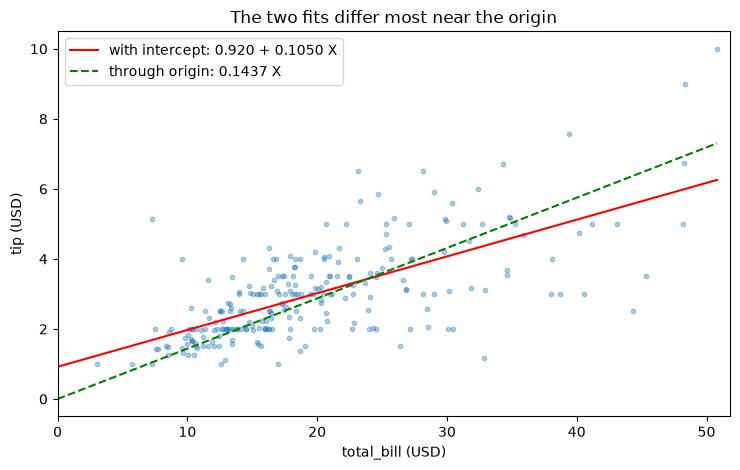

In [33]:
plt.figure(figsize=(7.5, 4.8))
plt.scatter(X, Y, s=10, alpha=.35)
xs = np.linspace(0, X.max(), 100)
plt.plot(xs, b0 + b1 * xs, 'r-', label=f'with intercept: {b0:.3f} + {b1:.4f} X')
plt.plot(xs, b1_o * xs, 'g--', label=f'through origin: {b1_o:.4f} X')
plt.xlim(0, X.max() + 1); plt.xlabel('total_bill (USD)'); plt.ylabel('tip (USD)')
plt.legend(); plt.title('The two fits differ most near the origin'); plt.tight_layout(); 

plt.savefig('images/The two fits differ most near the origin.png')
plt.show()

## Inverse prediction (calibration)

Given a new response $Y_{h(new)}$, estimate the $X$ that produced it by **inverting the fitted line**:

$$\hat X_{h(new)}=\frac{Y_{h(new)}-b_0}{b_1}.$$

Here: a tip of a given size — what bill is it consistent with? The slides say only that an approximate interval
"follows from the variance of $\hat X_{h(new)}$". The textbook approximation (not in the slides) is
$\hat X\pm t\,s\{\hat X\}$ with $s^2\{\hat X\}=\frac{MSE}{b_1^2}\left[1+\frac1n+\frac{(\hat X-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$,
which is only reasonable when $b_1$ is clearly non-zero. As a check, the cell below also inverts the **prediction band**
numerically — all $X$ whose pointwise 95% prediction interval contains $Y_{h(new)}$.

In [34]:
Y_new = 5.00                                              # a tip of 5 USD
X_hat = (Y_new - b0) / b1
s_Xhat = np.sqrt(MSE / b1 ** 2 * (1 + 1 / n + (X_hat - Xbar) ** 2 / Sxx))
approx = (X_hat - tcrit * s_Xhat, X_hat + tcrit * s_Xhat)

xg = np.linspace(X.min() - 5, X.max() + 25, 20001)
fg = b0 + b1 * xg
spg = np.sqrt(MSE * (1 + 1 / n + (xg - Xbar) ** 2 / Sxx))
ok = np.abs(Y_new - fg) <= tcrit * spg
band_inv = (xg[ok].min(), xg[ok].max())

print(f'tip = {Y_new:.2f}  ->  X_hat = ({Y_new} - {b0:.4f}) / {b1:.4f} = {X_hat:.2f} USD bill')
print(f'approximate 95% interval (textbook formula) : [{approx[0]:.2f}, {approx[1]:.2f}]')
print(f'inverting the 95% prediction band           : [{band_inv[0]:.2f}, {band_inv[1]:.2f}]')
print(f'observed bills range {X.min():.2f} - {X.max():.2f};  r = {r:.3f}\n')

# the tempting wrong move: regress X on Y and read off the bill
bx = ((X - Xbar) * (Y - Ybar)).sum() / Syy
X_rev = Xbar + bx * (Y_new - Ybar)
print(f'for comparison, regressing X on Y gives {X_rev:.2f} — a different answer (r = {r:.3f} < 1). '
      f'Slide 18 prescribes inverting the fitted Y-on-X line.')
print(f'the interval reaches {approx[1]:.1f}, beyond the largest observed bill ({X.max():.2f}): a single tip says little about the bill.')

tip = 5.00  ->  X_hat = (5.0 - 0.9203) / 0.1050 = 38.85 USD bill
approximate 95% interval (textbook formula) : [19.46, 58.23]
inverting the 95% prediction band           : [19.64, 58.79]
observed bills range 3.07 - 50.81;  r = 0.676

for comparison, regressing X on Y gives 28.49 — a different answer (r = 0.676 < 1). Slide 18 prescribes inverting the fitted Y-on-X line.
the interval reaches 58.2, beyond the largest observed bill (50.81): a single tip says little about the bill.


## Choice of the $X$ levels (design)

Every inference above depends on $\sum(X_i-\bar X)^2$:
$s^2\{b_1\}=MSE/\sum(X_i-\bar X)^2$, and $s\{\hat Y_h\}$ is smallest at $X_h=\bar X$.
This is an observational data set — the bills were not chosen by us — so the cell below only shows the *mechanism*:
holding $MSE$ fixed, how much does $s\{b_1\}$ change if the $X_i$ were concentrated or spread out?

In [35]:
q1, q3 = np.quantile(X, [.25, .75])
mid = X[(X >= q1) & (X <= q3)]
Sxx_mid = ((mid - mid.mean()) ** 2).sum()
Xhalf = np.concatenate([np.full(n // 2, X.min()), np.full(n - n // 2, X.max())])     # all cases at the two ends
Sxx_ends = ((Xhalf - Xhalf.mean()) ** 2).sum()

print('MSE held fixed at the full-data value, n as indicated\n')
print(f'{"X values used":<34}{"n":>5}{"sum(X-Xbar)^2":>16}{"s{b1}":>10}')
for lab, nn, ss in [('observed bills', n, Sxx),
                    ('middle half only (IQR)', len(mid), Sxx_mid),
                    ('all cases at min and max bill', n, Sxx_ends)]:
    print(f'{lab:<34}{nn:>5}{ss:>16,.1f}{np.sqrt(MSE/ss):>10.4f}')

print('\ns{Yhat_h} at several X_h (observed data):')
for xh in [Xbar, 10, 30, 45, 50.81]:
    print(f'  X_h = {xh:>6.2f}   s{{Yhat_h}} = {np.sqrt(MSE*(1/n + (xh-Xbar)**2/Sxx)):.4f}')
print('\nCaution (slide 19): spreading X to the extremes minimises s{b1} but leaves no way to see curvature in between;')
print('the end-point design is only safe if linearity is already established.')

MSE held fixed at the full-data value, n as indicated

X values used                         n   sum(X-Xbar)^2     s{b1}
observed bills                      244        19,258.5    0.0074
middle half only (IQR)              122         1,045.7    0.0316
all cases at min and max bill       244       139,025.6    0.0027

s{Yhat_h} at several X_h (observed data):
  X_h =  19.79   s{Yhat_h} = 0.0654
  X_h =  10.00   s{Yhat_h} = 0.0973
  X_h =  30.00   s{Yhat_h} = 0.0997
  X_h =  45.00   s{Yhat_h} = 0.1969
  X_h =  50.81   s{Yhat_h} = 0.2377

Caution (slide 19): spreading X to the extremes minimises s{b1} but leaves no way to see curvature in between;
the end-point design is only safe if linearity is already established.


## Procedures at a glance

For a family of statements compute both candidate multipliers and use the smaller. Below: $\alpha=0.05$,
$g=3$ statements, $n-2=242$.

In [36]:
rows = [
    ('beta0, beta1 jointly',       'Bonferroni',        stats.t.ppf(1 - fam_alpha / 4, n - 2)),
    ('mean responses, all X',      'Working-Hotelling', W),
    (f'mean responses, g = {g}',   'Bonferroni',        B_mean),
    (f'new observations, g = {g}', 'Scheffe',           S_mult),
    (f'new observations, g = {g}', 'Bonferroni',        B_mean),
    ('(one statement only)',       'pointwise t',       t_single),
]
print(f'{"target":<28}{"procedure":<20}{"multiplier":>11}')
for tgt, proc, m in rows:
    print(f'{tgt:<28}{proc:<20}{m:>11.4f}')

target                      procedure            multiplier
beta0, beta1 jointly        Bonferroni               2.2554
mean responses, all X       Working-Hotelling        2.4630
mean responses, g = 3       Bonferroni               2.4107
new observations, g = 3     Scheffe                  2.8153
new observations, g = 3     Bonferroni               2.4107
(one statement only)        pointwise t              1.9698


## What this chapter changes in the analysis (computed above, $\alpha=0.05$, $n=244$)

- **Joint vs. single.** Two separate 95% intervals covered *both* $\beta_0,\beta_1$ in 92.7% of 5000 simulated data sets
  (not 95%); the Bonferroni pair covered both in 96.2%, i.e. at least the 95% guaranteed and somewhat conservative.
  Multiplier $1.970\to2.255$. (Simulation scope: normal errors, the fitted line taken as truth, $X$ fixed.)
- **Which procedure wins depends on $g$.** For the mean response, Bonferroni beats Working–Hotelling ($W=2.463$) only for
  $g\le3$ ($B=2.411$ at $g=3$, $2.517$ at $g=4$). For $g=3$ predictions Bonferroni ($2.411$) also beats Scheffé ($2.815$).
- **A prediction interval is not a statement about the mean.** At $\bar X$ the $g=3$ prediction band is about 15 times
  wider than the Working–Hotelling band. Intervals for new tips are roughly $\pm2.5$ USD around a fitted value of 2–4 USD.
- **Prediction intervals lean on assumptions the diagnostics above put in doubt.** The pointwise 95% PI contained 97.5% /
  100% / 81.9% of the tips in the lowest / middle / highest third of bills (93.0% overall): constant width, but the scatter
  grows with the bill. This is consistent with the Brown–Forsythe and Breusch–Pagan outputs earlier in this notebook.
- **Through the origin** raises $b_1$ from $0.105$ to $0.144$, and the intercept test rejects $\beta_0=0$
  ($t^*=5.76$), so the data do not support forcing the line through 0 here. The reported "$R^2$" of $0.892$ is uncentred and
  must not be compared with $0.457$.
- **Inverse prediction** of the bill from a 5 USD tip gives $\hat X=38.85$ with an approximate interval $[19.5,\,58.2]$,
  wider than the observed range of bills: with $r=0.676$ the tip pins the bill down poorly.
- **Design.** $s\{b_1\}$ would be $0.0316$ if only the middle half of bills were observed (vs. $0.0074$ observed), and
  $s\{\hat Y_h\}$ at $X_h=45$ is three times its value at $\bar X$.

**Open item for the instructor:** slide 12 gives $B=2.263$ for $g=2$ at 90%; the slide-10 formula gives $2.069$.
